In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create simple 2D data that is correlated
np.random.seed(42)
x = np.linspace(0, 10, 50)
y = 2 * x + np.random.normal(0, 2, 50)
data = np.vstack((x, y)).T

# Center the data
# Subtract the mean of each column
mean_vec = np.mean(data, axis=0)
data_centered = data - mean_vec

print(f"Original Mean: {mean_vec}")
print(f"New Mean (should be ~0): {np.mean(data_centered, axis=0)}")

Original Mean: [5.         9.54905219]
New Mean (should be ~0): [7.10542736e-17 5.68434189e-16]


In [ ]:
# Formula: (X^T * X) / (n - 1)
cov_matrix = np.cov(data_centered.T)

print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[ 8.85047897 16.67459622]
 [16.67459622 34.78341858]]


In [ ]:
# Calculate eigenvectors and eigenvalues
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort them from largest to smallest
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"Principal Component 1 (Direction): {eigenvectors[:, 0]}")
print(f"Variance explained by PC1: {eigenvalues[0] / np.sum(eigenvalues):.2%}")

Principal Component 1 (Direction): [-0.4393961  -0.89829342]
Variance explained by PC1: 98.41%


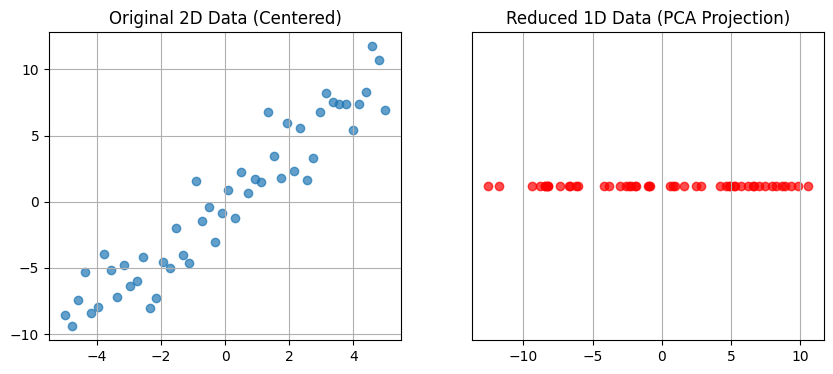

In [ ]:
# Take the first eigenvector (the best direction)
pc1 = eigenvectors[:, 0]

# Project the 2D data onto this 1D line
data_reduced = np.dot(data_centered, pc1)

# Plotting the result
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(data_centered[:, 0], data_centered[:, 1], alpha=0.7)
plt.title("Original 2D Data (Centered)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(data_reduced, np.zeros_like(data_reduced), color='r', alpha=0.7)
plt.title("Reduced 1D Data (PCA Projection)")
plt.yticks([]) # Hide Y axis as it's now 1D
plt.grid(True)

plt.show()